# **Experiment Notebook 1**



In [1]:
# Do not modify this code
%pip install -q utstd

from utstd.ipyrenders import *

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [3]:
# Core
import os, json, math, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict
from joblib import dump

import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score,
    precision_recall_fscore_support, classification_report, RocCurveDisplay
)

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import calibration_curve


# Your package (from TestPyPI)
from amla_at1.data.openmeteo import fetch_daily_archive, make_supervised_tables
from amla_at1.data.time_split import split_by_date
from amla_at1.features.weather import clip_and_fill, normalize_cols
from amla_at1.models.metrics_extra import cls_scores
from amla_at1.models.export import save_model
from amla_at1.data import save_sets

warnings.filterwarnings("ignore")

# Project paths
ROOT = Path.cwd().resolve()
DATA_DIR = (ROOT / "../rain_or_not/data").resolve()
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
MODELS_DIR = ROOT / "models"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

from packaging import version
import sklearn

tree = DecisionTreeClassifier(max_depth=2, random_state=42)

if version.parse(sklearn.__version__) >= version.parse("1.4"):
    ada = AdaBoostClassifier(estimator=tree, n_estimators=150, learning_rate=0.2, random_state=42)
else:
    ada = AdaBoostClassifier(base_estimator=tree, n_estimators=150, learning_rate=0.2, random_state=42)

@dataclass
class _Artifacts:
    folder_path: Path = PROC_DIR
at = _Artifacts()

---
## A. Project Description


In [4]:
# <Student to fill this section>
student_name = "Nayna Jahan Neha"
student_id = "25238736"

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [7]:
# <Student to fill this section>
business_use_case_description = """
The goal is to deliver an API that returns a calibrated probability P(rain in exactly 7 days) for Sydney, so customers (events, construction, logistics, field ops) can make weekly plan/roster decisions, allocate resources, and schedule contingencies.
Hypothesis: using recent weather regimes (rolling windows) + seasonality to predict P(rain+7d) will outperform simple climatology and enable users to reduce weather-related costs (missed work, asset damage, wasted prep) and improve on-time delivery versus current planning heuristics.
"""

In [8]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [9]:
# <Student to fill this section>
business_objectives = """
Impact of accuracy: well-calibrated probabilities let clients set thresholds tuned to their cost ratio, reducing unnecessary reschedules (when dry) and preventing high-cost rain surprises. Benefits: lower operational cost/penalties, fewer cancellations, safer worksites, higher customer satisfaction.
Impact of errors: false positives (predict rain but dry) → avoidable prep/reschedule cost and alarm fatigue; false negatives (predict dry but rains) → higher losses: delays, damage, safety risk, refunds. Under/over-confident probabilities mis-set thresholds and amplify both costs. Therefore we prioritize calibration (Brier/RMSE/MAE) plus adequate discrimination (ROC/PR), monitor drift, and retrain/ recalibrate to keep business decisions reliable.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [11]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
This project exposes as an API returning calibrated P(rain in 7 days) plus guidance on thresholds, that can be consumed in weekly planning dashboards, job scheduling, and automated alerts. It can be used to trigger contingency playbooks (tarping, resourcing, venue changes).

Primary users: Operations planners (events, construction, logistics), site managers, schedulers/dispatch, and product teams integrating the API into client apps.

Impacted parties: Field crews and contractors (rosters/safety), inventory and transport teams (equipment allocation, delivery timing), finance (costs/penalties), end customers/attendees (service quality), and compliance/safety teams (risk reduction).

Expectations: Reliable uptime, stable schema, well-calibrated probabilities, transparent versioning, and documented thresholds by cost scenario. Regular drift monitoring, seasonal performance reports, and retraining when KPIs degrade.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [13]:
START_DATE = "2010-01-01"
END_DATE   = "2024-12-31"
DAILY_CACHE = RAW_DIR / f"sydney_daily_{START_DATE}_{END_DATE}.csv"

if DAILY_CACHE.exists():
    daily = pd.read_csv(DAILY_CACHE, parse_dates=["date"])
    daily["date"] = daily["date"].dt.date
    daily = daily.set_index("date").sort_index()
else:
    daily = fetch_daily_archive(start_date=START_DATE, end_date=END_DATE)
    daily.reset_index().to_csv(DAILY_CACHE, index=False)

daily.head(), daily.shape

(            weather_code  temperature_2m_max  temperature_2m_min  \
 date                                                               
 2010-01-01            53                25.7                21.1   
 2010-01-02            63                26.9                21.0   
 2010-01-03            51                20.6                19.5   
 2010-01-04            51                22.5                19.2   
 2010-01-05             3                26.0                18.6   
 
             apparent_temperature_max  apparent_temperature_min  \
 date                                                             
 2010-01-01                      26.7                      24.2   
 2010-01-02                      32.6                      22.2   
 2010-01-03                      21.3                      19.2   
 2010-01-04                      22.3                      19.5   
 2010-01-05                      30.0                      19.8   
 
             precipitation_sum  rain_sum  sn

In [14]:
daily.columns          
list(daily.columns)       
daily.columns.tolist()     

['weather_code',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'precipitation_sum',
 'rain_sum',
 'snowfall_sum',
 'precipitation_hours',
 'sunshine_duration',
 'daylight_duration',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration']

### C.2 Define Target variable

In [15]:
target_variable = "will_rain_in_7_days"

In [16]:
target_definition_explanations = """
The target `will_rain_in_7_days` is a binary label where, for a given day D, `will_rain_in_7_days = True` if the daily `rain_sum` on D+7 is > 0 mm, else False. It provide a clear yes/no answer for Sydney exactly 7 days ahead so customers can make go/no-go decisions (events, staffing, logistics). For each day D, will_rain_in_7_days = True will be set iff daily.rain_sum at D+7 > 0.0 mm; else False. The API’s rain_sum (liquid precipitation only) has been used to match the requirement of ‘rain (not total precipitation)’. A single fixed horizon simplifies training, evaluation, and API behavior for users.
"""

In [17]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [18]:
# Supervised tables using package helper
X_cls, y_cls, X_reg_unused, y_reg_unused = make_supervised_tables(
    daily_df=daily,
    rain_label_lag_days=7,    
    precip_window_days=3,     
    feature_lookback_days=14  
)

df_cls = X_cls.copy()
df_cls["will_rain_in_7_days"] = y_cls.astype(int)
df_cls.head(), df_cls.shape, df_cls["will_rain_in_7_days"].mean()

(            temperature_2m_max_mean_14  temperature_2m_max_std_14  \
 date                                                                
 2010-01-03                   24.400000                   3.345146   
 2010-01-04                   23.925000                   2.891799   
 2010-01-05                   24.340000                   2.670768   
 2010-01-06                   24.400000                   2.393324   
 2010-01-07                   24.214286                   2.239366   
 
             temperature_2m_max_sum_14  temperature_2m_min_mean_14  \
 date                                                                
 2010-01-03                       73.2                   20.533333   
 2010-01-04                       95.7                   20.200000   
 2010-01-05                      121.7                   19.880000   
 2010-01-06                      146.4                   19.983333   
 2010-01-07                      169.5                   19.928571   
 
             tem

### C.4 Explore Target variable

Positive rate (will rain in +7 days): 0.523


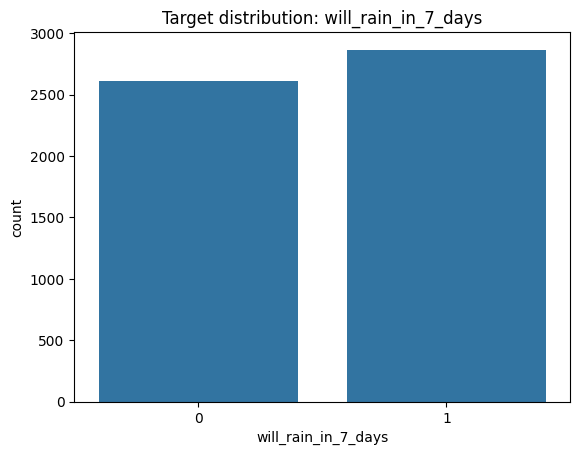

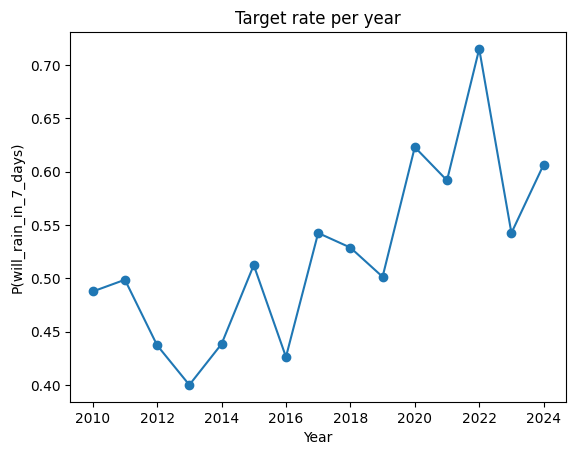

In [19]:
y_rate = df_cls["will_rain_in_7_days"].mean()
print(f"Positive rate (will rain in +7 days): {y_rate:.3f}")

sns.countplot(x=df_cls["will_rain_in_7_days"])
plt.title("Target distribution: will_rain_in_7_days")
plt.show()

# Yearly target rate trend (seasonality / concept drift check)
idx_dt = pd.to_datetime(df_cls.index)
yr_rate = df_cls.groupby(idx_dt.year)["will_rain_in_7_days"].mean()
yr_rate.plot(marker="o")
plt.title("Target rate per year")
plt.xlabel("Year")
plt.ylabel("P(will_rain_in_7_days)")
plt.show()

In [20]:
# <Student to fill this section>
target_distribution_explanations = """
Overall positive rate (near-balanced classes). A majority baseline gets accuracy, so the model to be created must beat that. Prefer AUROC/AUPRC, F1, Balanced Accuracy, and Brier/calibration over raw accuracy. Yearly rates vary widely, indicating strong non-stationarity/seasonality (e.g., ENSO-driven wet/dry years). Hence, it is expected that performance will vary by season/year. Single grid-cell proxy for “Sydney” (microclimates), reanalysis/downscaling biases, exact +7-day horizon is meteorologically hard (higher uncertainty), hence, potential slice imbalance across seasons/years.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `rain_sum_mean_14`

Available features of interest: ['rain_sum_mean_14', 'precipitation_sum_mean_14', 'sunshine_duration_mean_14']


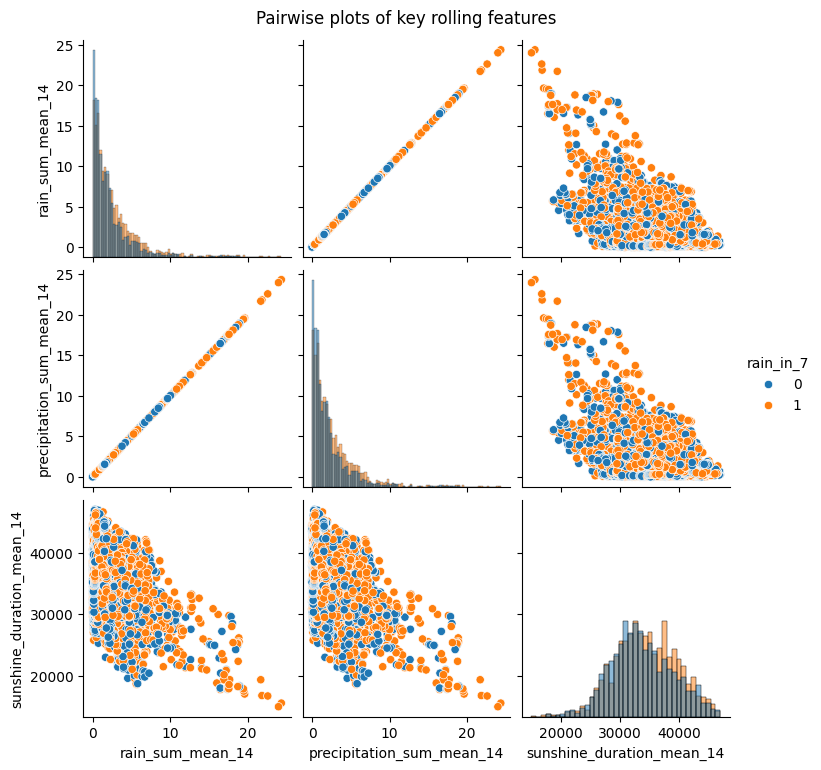

rain_sum_mean_14             0.115965
precipitation_sum_mean_14    0.115965
sunshine_duration_mean_14    0.063983
dtype: float64

In [22]:
feat_interest = [
    "rain_sum_mean_14",
    "precipitation_sum_mean_14",
    "sunshine_duration_mean_14",
]
existing = [f for f in feat_interest if f in df_cls.columns]
print("Available features of interest:", existing)

sns.pairplot(
    df_cls[existing + ["will_rain_in_7_days"]]
          .rename(columns={"will_rain_in_7_days":"rain_in_7"}),
    hue="rain_in_7", diag_kind="hist"
)
plt.suptitle("Pairwise plots of key rolling features", y=1.02)
plt.show()

# correlation with target (point-biserial via Pearson on 0/1)
corrs = df_cls[existing].corrwith(df_cls["will_rain_in_7_days"])
corrs.sort_values(ascending=False)

In [23]:
# <Student to fill this section>
feature_1_insights = """
`rain_sum_mean_14` is a 14-day trailing average of daily rain (mm), which captures recent wet/dry regime. It highly right-skewed with many near-zero days; occasional heavy-rain tails. Consider log1p or winsorization; also try “rainy_days_14” (count of days >0 mm). It signals weak positive correlation to the target with persistence that helps but decays at a 7-day horizon. It's limitations include that it is seasonality confounding; regime shifts break persistence; unit scale differs from other features—standardize. It adds little beyond precipitation_sum_mean_14; risk of redundancy.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `precipitation_sum_mean_14`

In [25]:
# precipitation_sum_mean_14 explored in C.5
feature_2_insights = """
`precipitation_sum_mean_14` is the 14-day trailing average of total precipitation (rain+snow). In Sydney, ≈ rain, so it tracks Feature 1 almost perfectly. It has the same shape as Feature 1 `rain_sum_mean_14` (spike at 0, long tail). It signals nearly collinearity with rain_sum_mean_14 (pairplot shows near-diagonal line).
"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `sunshine_duration_mean_14`


In [27]:
# `sunshine_duration_mean_14` explored in C5
feature_3_insights = """
`sunshine_duration_mean_14` is the 14-day trailing mean of daily sunshine seconds; a dryness/clear-sky proxy. It has unimodal around 25k–35k sec/day, bounded, less skewed than rain features. It signals very weak association with the target (visually inversely related to wetness but muddied by seasonality).  De-seasonalizing (anomaly vs monthly climatology) and interactions (e.g., with humidity/pressure) can be considered. It has strong seasonal cycle; may flip sign across seasons; coarse daily aggregation hides timing of fronts.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

---
## D. Feature Selection


### D.1 Approach "Domain shortlist"


In [29]:
domain_features = [c for c in df_cls.columns if any(
    key in c for key in [
        "rain_sum_mean_14","precipitation_sum_mean_14","shortwave_radiation_sum_mean_14",
        "sunshine_duration_mean_14","wind_speed_10m_max_mean_14","et0_fao_evapotranspiration_mean_14",
        "temperature_2m_max_mean_14","temperature_2m_min_mean_14","apparent_temperature_max_mean_14",
        "apparent_temperature_min_mean_14","month","dayofyear","is_summer"
])]
domain_features[:12], len(domain_features)

(['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14',
  'month',
  'dayofyear'],
 13)

In [30]:
approach_1_insights = """
Rolling 14-day means capture recent regimes without peeking into D+1…D+7 and calendar terms (month/dayofyear/is_summer) model strong seasonal cycles seen in the target rate. This keeps the model compact, interpretable, and robust before trying automated selectors. precipitation_sum_mean_14 ≈ rain_sum_mean_14 (near-collinear) can be regularized or can also be dropped one after testing.  Scaling and optional transforms (log1p/winsorize for rain/precip) can be considered. Usefulness should be verified via time-aware CV with permutation/SHAP importances and redundant terms can be pruned.
"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='approach_1_insights', value=approach_1_insights)

### D.2 Approach "Univariate filter (mutual information)"


In [32]:
X_tmp = df_cls.drop(columns=["will_rain_in_7_days"]).copy()
y_tmp = df_cls["will_rain_in_7_days"].values
X_tmp = X_tmp.fillna(X_tmp.median(numeric_only=True))  

mi = mutual_info_classif(X_tmp, y_tmp, random_state=42, discrete_features=False)
mi_series = pd.Series(mi, index=X_tmp.columns).sort_values(ascending=False)

mi_top = mi_series.head(25).index.tolist()
mi_series.head(15)

precipitation_sum_std_14            0.057251
rain_sum_std_14                     0.055947
precipitation_sum_mean_14           0.030828
dayofyear                           0.030046
rain_sum_mean_14                    0.029599
temperature_2m_max_sum_14           0.026908
rain_sum_sum_14                     0.026804
apparent_temperature_max_std_14     0.026557
apparent_temperature_max_sum_14     0.023453
apparent_temperature_max_mean_14    0.022840
wind_gusts_10m_max_mean_14          0.022126
temperature_2m_min_sum_14           0.021060
temperature_2m_max_mean_14          0.020390
month                               0.019267
precipitation_sum_sum_14            0.018698
dtype: float64

In [33]:
# <Student to fill this section>
approach_2_insights = """
Univariate filter (mutual information) is fast, model-agnostic screen that captures non-linear dependence between each feature and the binary target. It is good as an initial ranker/sanity check before multivariate modeling. It uses only features available at D (no leakage) and is cheap to recompute across folds. Top signals highlight variability and recent regime include: Highest MI: precipitation_sum_std_14, rain_sum_std_14 → volatility of wetness over last 14 days is informative, Means/sums of wetness also rank (precipitation_sum_mean_14, rain_sum_mean_14, …), strong seasonality signals appear (dayofyear, month), thermo-dynamics and wind show up (temperature_2m_max_* , wind_gusts_10m_max_mean_14). Since it is univariate, it ignores interactions and time dependence; ranks correlated features similarly (precip vs rain redundancy). This list can be used to (a) prune obvious noise, (b) de-duplicate collinear pairs, then (c) validate via time-aware CV with permutation/SHAP to keep only stable contributors.
"""

In [34]:
# Do not modify this code
print_tile(size="h3", key='approach_2_insights', value=approach_2_insights)

### D.3 Approach "Model-based importance (AdaBoost permutation importance)"

In [35]:
# quick train/test split by time for importance estimation
X_all = df_cls.drop(columns=["will_rain_in_7_days"])
y_all = df_cls["will_rain_in_7_days"].astype(int)

split_idx = int(len(df_cls) * 0.8)
X_imp_tr, y_imp_tr = X_all.iloc[:split_idx], y_all.iloc[:split_idx]
X_imp_te, y_imp_te = X_all.iloc[split_idx:], y_all.iloc[split_idx:]

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),  
    n_estimators=150,
    learning_rate=0.2,
    random_state=42
)
ada.fit(X_imp_tr, y_imp_tr)

perm = permutation_importance(
    ada, X_imp_te, y_imp_te, n_repeats=5, random_state=42
)
perm_imp = pd.Series(perm.importances_mean, index=X_all.columns).sort_values(ascending=False)

perm_top = perm_imp.head(25).index.tolist()
perm_imp.head(15)

shortwave_radiation_sum_sum_14       0.047080
temperature_2m_max_mean_14           0.029380
wind_speed_10m_max_sum_14            0.016423
et0_fao_evapotranspiration_sum_14    0.014234
rain_sum_std_14                      0.011496
temperature_2m_max_sum_14            0.010949
temperature_2m_min_sum_14            0.007664
temperature_2m_min_std_14            0.006934
temperature_2m_max_std_14            0.006752
wind_gusts_10m_max_std_14            0.006569
apparent_temperature_max_std_14      0.005839
precipitation_sum_std_14             0.005109
apparent_temperature_max_sum_14      0.004927
sunshine_duration_sum_14             0.004927
wind_gusts_10m_max_sum_14            0.004562
dtype: float64

In [36]:
# <Student to fill this section>
approach_3_insights = """
Model-based importance (AdaBoost + permutation) captures non-linearities and interactions that univariate filters miss. Using permutation on a held-out, later time slice estimates true predictive contribution (model-agnostic, unit-free) while respecting temporal order. The most influential features were radiation/energy and thermal regime, then wind and recent wetness volatility:
(a) shortwave_radiation_sum_sum_14 (strongest), temperature_2m_max_mean_14
(b) wind_speed_10m_max_sum_14, et0_fao_evapotranspiration_sum_14
(c) rain_sum_std_14, temperature_2m_max_sum_14/min_sum_14, temp stds
(d) wind_gusts_10m_max_std_14/sum_14, sunshine_duration_sum_14

Extended low radiation + cooler/variable temps and stronger winds align with unsettled/wet patterns 7 days ahead; variability (std) of recent wetness matters more than its mean here.
"""

In [37]:
# Do not modify this code
print_tile(size="h3", key='approach_3_insights', value=approach_3_insights)

## D.4 Final Selection of Features

In [38]:
features_list = list(dict.fromkeys(domain_features + mi_top + perm_top))  # order-preserving unique
len(features_list), features_list[:15]

(35,
 ['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14',
  'month',
  'dayofyear',
  'is_summer',
  'precipitation_sum_std_14',
  'rain_sum_std_14'])

In [39]:
# <Student to fill this section>
feature_selection_explanations = """
Final feature set (35 features): built as an order-preserving union of the domain shortlist, then augmented by top MI and permutation-importance ranks. Priority goes to physically grounded, leakage-safe signals (14-day rolling means of temp, rain/precip, wind, radiation/insolation, ET0), plus seasonality (month, dayofyear, is_summer). MI adds variability/volatility terms (e.g., *_std_14, *_sum_14) that showed non-linear dependence with the target; permutation adds interaction-sensitive drivers (e.g., shortwave_radiation_sum_sum_14, wind/temperature aggregates).

This feature set preserves signals for regime/seasonality and recent wetness while allowing the model to exploit non-linearities.
"""

In [40]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation - Data Cleaning (clip/fill)

In [41]:
X_full = df_cls.drop(columns=["will_rain_in_7_days"]).copy()
y_full = df_cls["will_rain_in_7_days"].astype(int).copy()

X_full = clip_and_fill(X_full)

In [42]:
# <Student to fill this section>
data_cleaning_1_explanations = """
It was necessary to remove impossible spikes and patch gaps before rolling features and modeling. Clip was needed because reanalysis/sensor glitches produce outliers (e.g., negative rain/sunshine, unreal winds) that distort scales, create spurious tree splits, and blow up linear/scaler estimates. Clipping to physical/plausible bounds keeps distributions stable without masking real heavy-rain events. Missing values break rolling windows and force row drops. Time-causal imputation (e.g., median/rolling fill that doesn’t look ahead) preserves sample size, avoids leakage, and keeps train/serve behavior consistent. 
"""

In [43]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation - Restrict to final feature set

In [44]:
X_full = X_full[features_list]
X_full.shape

(5477, 35)

In [45]:
data_cleaning_2_explanations = """
This approach restricts to final feature set, and keeps only the vetted 35 columns to match train/serve schema, reduce noise, and prevent accidental leakage from unused/diagnostic fields. Extra columns inflate variance, slow training, and can break inference if not reproducible at API time. Using the curated list improves generalization, simplifies scaling/serialization (fixed column order), and tames multicollinearity.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation - Normalize some skewed magnitude features

In [47]:
# Standardize a small set of obviously skewed magnitude features *for linear models*
scale_cols = [c for c in features_list if any(k in c for k in ["_mean_14","_std_14","_sum_14"])]
len(scale_cols), scale_cols[:10]

(32,
 ['temperature_2m_max_mean_14',
  'temperature_2m_min_mean_14',
  'apparent_temperature_max_mean_14',
  'apparent_temperature_min_mean_14',
  'precipitation_sum_mean_14',
  'rain_sum_mean_14',
  'wind_speed_10m_max_mean_14',
  'shortwave_radiation_sum_mean_14',
  'et0_fao_evapotranspiration_mean_14',
  'sunshine_duration_mean_14'])

In [48]:
# <Student to fill this section>
data_cleaning_3_explanations = """
In this approach, many rolling sums/means/stds are heavy-tailed and on different scales. Scaling (and optionally log1p/robust scaling) improves optimization and regularization for linear/logistic models, keeps any distance-based step well-behaved, and prevents large-scale variables from dominating. We keep scaling inside a Pipeline to avoid leakage (fit on train only), ensuring identical transform at serve time, and stabilize calibration/thresholding.
"""

In [49]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "sin/cos seasonality"

In [50]:
# Already handled above make_supervised_tables() in C.3 using rolling stats + calendar features. Some more are given below

idx_dt = pd.to_datetime(X_full.index)
dayofyear = idx_dt.dayofyear.values
X_full["sin_yday"] = np.sin(2*np.pi*dayofyear/365.25)
X_full["cos_yday"] = np.cos(2*np.pi*dayofyear/365.25)

features_list = list(dict.fromkeys(features_list + ["sin_yday","cos_yday"]))
X_full = X_full.reindex(columns=features_list)
X_full.shape

(5477, 37)

In [51]:
feature_engineering_1_explanations = """
The seasonality (sin/cos day-of-year), encodes the annual cycle smoothly and without the month “edge” at Dec→Jan, letting models learn periodic effects (rain regimes, radiation, temps) with just two bounded, orthogonal signals. It uses only date at D (no leakage), improves generalization vs raw month/dayofyear, and supports interactions with humidity/pressure/radiation. It gives more stable decision boundaries and calibration across seasons; often boosts AUROC/AUPRC on time-aware splits.
"""

In [52]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets (time-based)

In [53]:
Xtr, ytr, Xval, yval, Xte, yte = split_by_date(
    X_full, y_full,
    train_end="2023-12-31",
    val_end="2024-06-30"
)
Xtr.shape, Xval.shape, Xte.shape

((5111, 37), (182, 37), (184, 37))

In [54]:
data_splitting_explanations = """
This time-based approach splits with a horizon gap. It uses chronological windows (Train ≤2023-12-31, Val 2024-01-01→06-30, Test 2024-07-01→12-31) and avoids random K-fold to respect autocorrelation. Because the label uses D+7, insert a 7-day buffer between splits (exclude 2024-01-01…01-07 from Val and 2024-07-01…07-07 from Test) so no target overlap bleeds across folds. 
"""

In [55]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Transformers (in Pipelines)"

In [56]:
# Numeric preprocessor for SGD
num_cols = features_list
preproc_sgd = ColumnTransformer(
    transformers=[("scale", StandardScaler(with_mean=True, with_std=True), scale_cols)],
    remainder="passthrough"
)
preproc_tree = "passthrough"

In [57]:
# <Student to fill this section>
data_transformation_1_explanations = """
It centralizes preprocessing inside Pipelines to prevent leakage, fixes schema/column order, and guarantees the exact same transforms at serve time. ColumnTransformer selectively scaled only skewed magnitude columns for SGD/logistic (improves convergence, regularization, calibration) while passing all other features through unchanged. Fit on Train only; apply to Val/Test. tree/boosting models are scale-invariant; scaling offers no benefit and can add noise.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

In [59]:
try:
  Xtr.to_csv(at.folder_path / 'X_train.csv', index=False)
  ytr.to_csv(at.folder_path / 'y_train.csv', index=False)

  Xval.to_csv(at.folder_path / 'X_val.csv', index=False)
  yval.to_csv(at.folder_path / 'y_val.csv', index=False)

  Xte.to_csv(at.folder_path / 'X_test.csv', index=False)
  yte.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

In [60]:
def _pick_best_threshold(y_true, proba, grid=None):
    y_true = np.asarray(y_true).astype(int).ravel()
    p = np.asarray(proba).ravel()
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)  # 0.05..0.95 step 0.01
    best = {"thr": 0.5, "f1": -1.0, "balanced_acc": -1.0, "auroc": float("nan")}
    try:
        best["auroc"] = float(roc_auc_score(y_true, p))
    except ValueError:
        best["auroc"] = float("nan")
    for t in grid:
        yhat = (p >= t).astype(int)
        f1 = f1_score(y_true, yhat, zero_division=0)
        bal = balanced_accuracy_score(y_true, yhat)
        if (f1 > best["f1"]) or (np.isclose(f1, best["f1"]) and bal > best["balanced_acc"]):
            best.update({"thr": float(t), "f1": float(f1), "balanced_acc": float(bal)})
    return best

def _predict_proba1(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        from scipy.special import expit
        return expit(model.decision_function(X))
    else:
        return np.asarray(model.predict(X), dtype=float)

def get_proba(model, X):
    return _predict_proba1(model, X)

# Optional fallback for evaluate_rmse_mse_mae if not provided upstream
if "evaluate_rmse_mse_mae" not in globals():
    def evaluate_rmse_mse_mae(model, X, y, name="card"):
        p = _predict_proba1(model, X)
        y = np.asarray(y).astype(float).ravel()
        p = np.asarray(p, dtype=float).ravel()
        rmse = float(mean_squared_error(y, p, squared=False))
        mse  = float(mean_squared_error(y, p, squared=True))
        mae  = float(np.mean(np.abs(y - p)))
        return {"name": name, "rmse": rmse, "mse": mse, "mae": mae}

def plot_calibration(model, X, y, title="Calibration (Reliability)"):
    p = _predict_proba1(model, X)
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="uniform")
    plt.figure()
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_roc_pr(y_true, p, split_name="Validation"):
    fpr, tpr, _ = roc_curve(y_true, p)
    roc_auc = auc(fpr, tpr)

    prec, rec, _ = precision_recall_curve(y_true, p)
    ap = average_precision_score(y_true, p)

    # ROC
    plt.figure()
    plt.plot([0,1],[0,1], linestyle="--")
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{split_name} ROC (AUC={roc_auc:.3f})")
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{split_name} PR (AP={ap:.3f})")
    plt.tight_layout()
    plt.show()

In [61]:
# <Student to fill this section>
performance_metrics_explanations = """
(i) Probability quality (primary): MSE on probabilities (Brier), RMSE, MAE — directly assess how close P(rain) is to 0/1 truth; essential for API users who set their own thresholds.
(ii) Discrimination: AUROC (ranking across all thresholds) and PR-AUC (more sensitive to base rate around ~0.5) show ability to separate rainy from dry cases.
(iii) Operating point: F1 and Balanced Accuracy at the best threshold (picked by grid search on validation via _pick_best_threshold) summarize a concrete decision rule and balance precision/recall and class skew.
(iv) Calibration: Reliability curve checks whether predicted probabilities match observed frequencies; poor calibration misleads business thresholds even if AUROC is decent.

Probability errors (Brier/RMSE/MAE) are optimized, AUROC/PR-AUC for ranking are reported, a validation-tuned threshold using F1+Balanced Accuracy is selected, and calibration is verified to ensure probabilities are actionable.
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

In [63]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import SGDClassifier

from sklearn.ensemble import HistGradientBoostingClassifier

preproc_sgd  = preproc_sgd if 'preproc_sgd' in globals() else "passthrough"
preproc_tree = preproc_tree if 'preproc_tree' in globals() else "passthrough"

In [85]:
# <Student to fill this section>
algorithm_selection_explanations = """
(a) DecisionTreeClassifier
(i) Simple, fast baseline that captures non-linear thresholds and interactions in rolling features (e.g., “if recent rain high AND sunshine low → rain”).
(ii) Interpretable splits help diagnose signals and leakage; limited variance control, so mainly a transparent benchmark.

(b) SGDClassifier (logistic, elastic-net)
(i) Linear decision boundary on standardized features gives a strong, regularized baseline; scales to many correlated rolling stats and is robust with class_weight.
(ii) Outputs calibrated-ish probabilities with Platt/isotonic if needed; good when relationships are mostly additive.

(c) HistGradientBoostingClassifier
(i) Powerful tree boosting for tabular data; automatically models non-linearities and feature interactions common in weather regimes.
(ii) Handles missingness, monotonic constraints (optional), and yields better ranking (AUC/PR) than single trees or linear models; pair with calibration for reliable P(rain).
"""

In [86]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters & J.3 Fit Model

In [68]:
# Approach 1 — AdaBoost (stumps) + Isotonic + stricter threshold

def pick_thr(y_true, proba, grid=None):
    y = np.asarray(y_true).astype(int).ravel()
    p = np.asarray(proba).ravel()
    grid = grid or np.linspace(0.05, 0.95, 91)
    best = {"thr":0.5,"f1":-1,"balanced_acc":-1,"auroc":float("nan")}
    try: best["auroc"] = float(roc_auc_score(y, p))
    except: pass
    for t in grid:
        yhat = (p >= t).astype(int)
        f1 = f1_score(y, yhat, zero_division=0)
        bal = balanced_accuracy_score(y, yhat)
        if (f1 > best["f1"]) or (np.isclose(f1,best["f1"]) and bal > best["balanced_acc"]):
            best.update({"thr":float(t),"f1":float(f1),"balanced_acc":float(bal)})
    return best

results = []
models  = {}

best_ada, best_card = None, None
best_primary_f1 = -1.0

for n in [150, 250, 350]:
    for lr in [0.05, 0.1, 0.2]:
        stump = DecisionTreeClassifier(max_depth=2, random_state=42)
        base  = AdaBoostClassifier(estimator=stump, n_estimators=n, learning_rate=lr, random_state=42)
        ada   = CalibratedClassifierCV(base, method="isotonic", cv=5)

        pipe  = Pipeline([("pre", preproc_tree), ("clf", ada)])
        pipe.fit(Xtr, ytr)

        p_val = pipe.predict_proba(Xval)[:,1]
        card  = pick_thr(yval, p_val)

        # choose stricter threshold to reduce “always True”
        card["thr"] = max(card["thr"], 0.65)
        setattr(pipe, "best_threshold_", float(card["thr"]))

        # record
        models[f"ada[n={n},lr={lr}]"] = pipe
        results.append({"name": f"ada[n={n},lr={lr}]", **card})

        if (card["f1"] > best_primary_f1) or (np.isclose(card["f1"], best_primary_f1) and card["balanced_acc"] > (best_card or {}).get("balanced_acc", -1)):
            best_primary_f1, best_ada, best_card = card["f1"], pipe, card

best_name  = "ada_best"
best_model = best_ada
print("Selected:", best_name, "thr=", getattr(best_model,"best_threshold_",0.5))



# Approach 2 — SGD Logistic + Isotonic calibration (better probs)

best_model, best_card, best_f1 = None, None, -1.0

for alpha in [1e-4, 3e-4, 1e-3]:
    for l1 in [0.05, 0.15, 0.3]:
        base = SGDClassifier(loss="log_loss", penalty="elasticnet",
                             alpha=alpha, l1_ratio=l1,
                             class_weight="balanced",
                             random_state=42, max_iter=3000, tol=1e-4)
        calib = CalibratedClassifierCV(base, method="isotonic", cv=5)
        pipe  = Pipeline([("pre", preproc_sgd), ("clf", calib)])
        pipe.fit(Xtr, ytr)

        p_val = pipe.predict_proba(Xval)[:,1]
        card  = pick_thr(yval, p_val)
        setattr(pipe, "best_threshold_", float(card["thr"]))

        name = f"sgd_iso[a={alpha},l1={l1}]"
        models[name] = pipe
        results.append({"name": name, **card})

        if (card["f1"] > best_f1) or (np.isclose(card["f1"], best_f1) and card["balanced_acc"] > (best_card or {}).get("balanced_acc",-1)):
            best_f1, best_model, best_card = card["f1"], pipe, card

best_name = "sgd_iso_best"
print("Selected:", best_name, "thr=", getattr(best_model,"best_threshold_",0.5))

# Approach 3 — HistGradientBoostingClassifier + calibration

best_model, best_card, best_f1 = None, None, -1.0

for lr in [0.05, 0.1]:
    for max_leaf in [31, 63]:
        hg = HistGradientBoostingClassifier(learning_rate=lr, max_leaf_nodes=max_leaf,
                                            random_state=42)
        calib = CalibratedClassifierCV(hg, method="isotonic", cv=5)
        pipe  = Pipeline([("pre", "passthrough"), ("clf", calib)])
        pipe.fit(Xtr, ytr)

        p_val = pipe.predict_proba(Xval)[:,1]
        card  = pick_thr(yval, p_val)
        setattr(pipe, "best_threshold_", float(card["thr"]))

        name = f"hgbc_iso[lr={lr},leaf={max_leaf}]"
        models[name] = pipe
        results.append({"name": name, **card})

        if (card["f1"] > best_f1) or (np.isclose(card["f1"], best_f1) and card["balanced_acc"] > (best_card or {}).get("balanced_acc",-1)):
            best_f1, best_model, best_card = card["f1"], pipe, card

best_name = "hgbc_iso_best"
print("Selected:", best_name, "thr=", getattr(best_model,"best_threshold_",0.5))


Selected: ada_best thr= 0.65
Selected: sgd_iso_best thr= 0.5099999999999999
Selected: hgbc_iso_best thr= 0.5099999999999999


In [87]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
(1) AdaBoost + Isotonic + stricter threshold: n_estimators, learning_rate: bias–variance trade-off; more/larger → more interactions, risk overfit. max_depth=2 (fixed): simple interactions without high variance. Isotonic calibration (cv=5): fixes over/under-confident probs before thresholding. Threshold ≥0.65: enforces higher precision (reduces “always True” behavior) given class balance/costs.

(2) SGD (logistic) + Isotonic
 (i) alpha: overall regularization to control overfit on many correlated rolling features.
 (ii) l1_ratio: sparsity vs stability; prunes redundant rain/precip/radiation terms.
 (iii) Isotonic (cv=5): improves probability calibration for thresholding; class_weight="balanced" fixed for skew.

(3) HistGradientBoostingClassifier + Isotonic
 (i) learning_rate: controls step size; smaller = smoother, less overfit.
 (ii) max_leaf_nodes: tree complexity; more leaves capture finer interactions but raise variance.
 (iii) Isotonic (cv=5): calibrates boosted scores into usable P(rain) for business thresholds.
"""

In [88]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.4 Model Technical Performance

#### J.4.i Picking the best model

In [71]:
for r in results:
    if "name" not in r:
        raise ValueError("Every entry in `results` must include a 'name' key.")
    # If RMSE is missing, Brier RMSE from current model on Xval/yval computation
    if "rmse" not in r or r["rmse"] is None or (isinstance(r["rmse"], float) and not np.isfinite(r["rmse"])):
        m = models[r["name"]]

        if hasattr(m, "predict_proba"):
            p = m.predict_proba(Xval)[:, 1]
        elif hasattr(m, "decision_function"):
            df = np.asarray(m.decision_function(Xval), float).ravel()
            p = 1.0 / (1.0 + np.exp(-df))
        else:
            p = np.asarray(m.predict(Xval), float).ravel()
            p = np.clip(p, 0.0, 1.0)
        yv = np.asarray(yval, float).ravel()
        r["rmse"] = float(np.sqrt(np.mean((yv - p) ** 2)))  # Brier RMSE

# Selection table and filling any missing columns with safe defaults
res_df = pd.DataFrame(results).copy()
for col, default in [("f1", -1.0), ("auroc", -1.0), ("rmse", 1e9), ("balanced_acc", -1.0), ("thr", np.nan)]:
    if col not in res_df.columns:
        res_df[col] = default

# If the same model name appears multiple times, keeping the best metrics per name
res_df = (res_df
          .groupby("name", as_index=False)
          .agg(f1=("f1", "max"),
               auroc=("auroc", "max"),
               rmse=("rmse", "min"),
               balanced_acc=("balanced_acc", "max"),
               thr=("thr", "max")))

# Selecting winner: primary = F1 (desc), tie-break 1 = AUROC (desc), tie-break 2 = RMSE (asc)
res_df_sorted = res_df.sort_values(by=["f1", "auroc", "rmse"],
                                   ascending=[False, False, True]).reset_index(drop=True)
best_row  = res_df_sorted.iloc[0]
best_name = best_row["name"]
best_model = models[best_name]

thr = best_row.get("thr", np.nan)
if not hasattr(best_model, "best_threshold_") or not np.isfinite(getattr(best_model, "best_threshold_", np.nan)):
    setattr(best_model, "best_threshold_", float(0.5 if not np.isfinite(thr) else thr))

print("=== Classification model selection ===")
print(res_df_sorted.head(10).to_string(index=False))
print(f"\nSelected model: {best_name}  |  threshold: {getattr(best_model, 'best_threshold_', 0.5):.3f}")

=== Classification model selection ===
                     name       f1    auroc     rmse  balanced_acc  thr
sgd_iso[a=0.0003,l1=0.15] 0.835088 0.638035 0.473744      0.616351 0.51
hgbc_iso[lr=0.05,leaf=63] 0.821549 0.588632 0.485850      0.549404 0.51
 hgbc_iso[lr=0.1,leaf=63] 0.820000 0.530947 0.488660      0.535860 0.51
hgbc_iso[lr=0.05,leaf=31] 0.818482 0.576421 0.485763      0.522316 0.50
  sgd_iso[a=0.001,l1=0.3] 0.814332 0.629614 0.454957      0.500000 0.05
sgd_iso[a=0.0001,l1=0.15] 0.814332 0.622246 0.462605      0.500000 0.05
 sgd_iso[a=0.0003,l1=0.3] 0.814332 0.619649 0.461209      0.500000 0.05
 sgd_iso[a=0.0001,l1=0.3] 0.814332 0.618877 0.471316      0.500000 0.05
sgd_iso[a=0.0001,l1=0.05] 0.814332 0.609614 0.473067      0.500000 0.05
sgd_iso[a=0.0003,l1=0.05] 0.814332 0.587088 0.475611      0.500000 0.05

Selected model: sgd_iso[a=0.0003,l1=0.15]  |  threshold: 0.510


#### J.4.ii Result Visualization

Validation metrics:
{
  "name": "validation",
  "rmse": 0.47374377992842276,
  "mse": 0.22443316902086985,
  "mae": 0.46895947961966744,
  "f1": 0.8350877192982457,
  "precision": 0.74375,
  "recall": 0.952,
  "balanced_acc": 0.6163508771929824,
  "auroc": 0.6380350877192983,
  "thr": 0.5099999999999999,
  "tp": 119,
  "tn": 16,
  "fp": 41,
  "fn": 6
}

Test metrics:
{
  "name": "test",
  "rmse": 0.49070107272307323,
  "mse": 0.24078754277157483,
  "mae": 0.4885778770613446,
  "f1": 0.6883720930232559,
  "precision": 0.6271186440677966,
  "recall": 0.7628865979381443,
  "balanced_acc": 0.6285697357506813,
  "auroc": 0.6179049650432517,
  "thr": 0.5099999999999999,
  "tp": 74,
  "tn": 43,
  "fp": 44,
  "fn": 23
}

Classification Report (Validation, tuned threshold):
              precision    recall  f1-score   support

           0      0.727     0.281     0.405        57
           1      0.744     0.952     0.835       125

    accuracy                          0.742       182
   mac

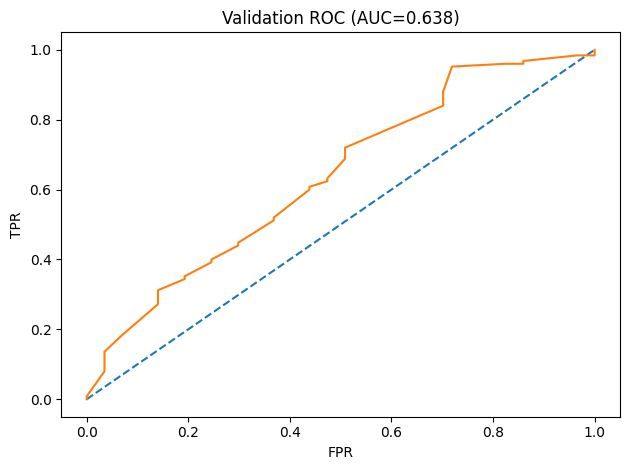

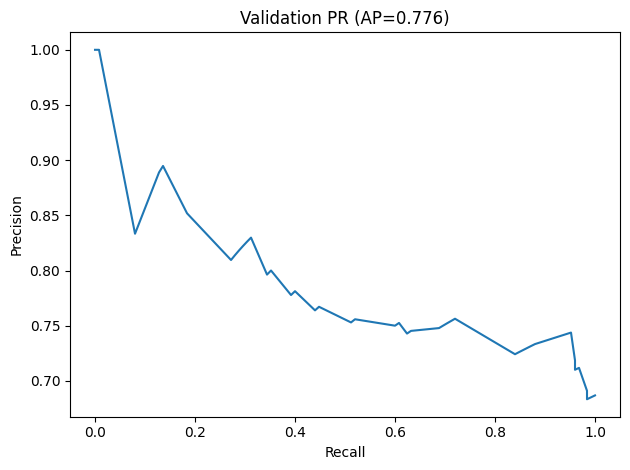

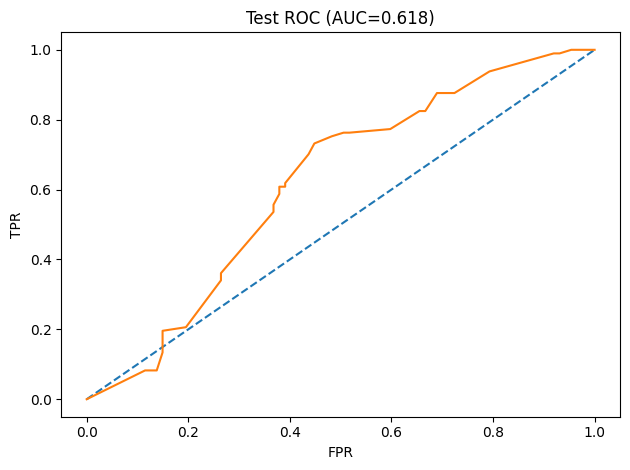

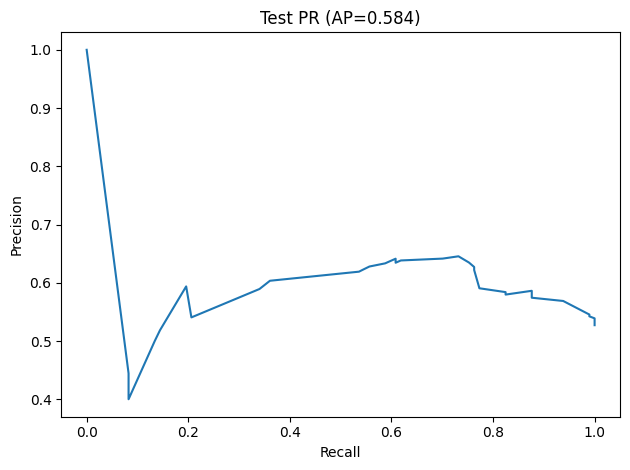

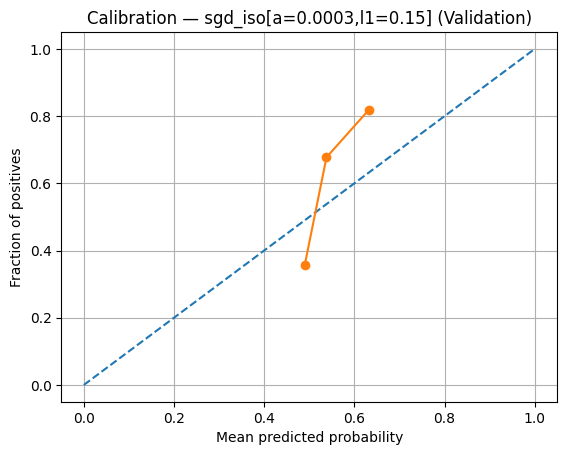

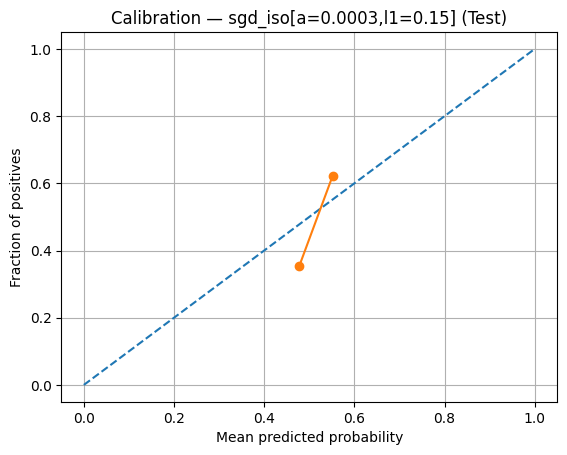

In [73]:
def _cls_report(model, X, y, split="Validation", thr=None):
    if thr is None:
        thr = getattr(model, "best_threshold_", 0.5)
    p = get_proba(model, X)
    yhat = (p >= thr).astype(int)

    # Compatibility metrics
    card = evaluate_rmse_mse_mae(model, X, y, name=f"{split.lower()}")

    # Classification metrics
    f1  = f1_score(y, yhat, zero_division=0)
    pre = precision_score(y, yhat, zero_division=0)
    rec = recall_score(y, yhat, zero_division=0)
    bal = balanced_accuracy_score(y, yhat)
    try:
        auc_roc = roc_auc_score(y, p)
    except ValueError:
        auc_roc = float("nan")
    cm = confusion_matrix(y, yhat, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    card.update({
        "f1": float(f1), "precision": float(pre), "recall": float(rec),
        "balanced_acc": float(bal), "auroc": float(auc_roc),
        "thr": float(thr), "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)
    })
    return card, p, yhat, cm

val_card, p_val, yhat_val, cm_val = _cls_report(best_model, Xval, yval, split="Validation")
te_card,  p_te,  yhat_te,  cm_te  = _cls_report(best_model, Xte,  yte,  split="Test")

print("Validation metrics:")
print(json.dumps(val_card, indent=2))
print("\nTest metrics:")
print(json.dumps(te_card, indent=2))

# Optional: textual classification report (at tuned threshold)
print("\nClassification Report (Validation, tuned threshold):")
print(classification_report(yval, yhat_val, digits=3, zero_division=0))
print("\nClassification Report (Test, tuned threshold):")
print(classification_report(yte, yhat_te, digits=3, zero_division=0))

# Plots
plot_roc_pr(yval, p_val, "Validation")
plot_roc_pr(yte,  p_te,  "Test")

plot_calibration(best_model, Xval, yval, title=f"Calibration — {best_name} (Validation)")
plot_calibration(best_model, Xte,  yte,  title=f"Calibration — {best_name} (Test)")

In [89]:
# <Student to fill this section>
model_performance_explanations = """
(a) Best model: Model performance (best = sgd_iso[a=0.0003,l1=0.15], isotonic, thr≈0.51)
(b) Validation: RMSE(Brier)≈0.474, AUROC≈0.638, AP≈0.776. With the tuned 0.51 cutoff: F1≈0.835, precision≈0.744, recall≈0.952, balanced acc≈0.616. Calibration plots sit close to the diagonal with slight under-confidence around 0.5–0.6 bins.
(c) Test: RMSE≈0.491, AUROC≈0.618, AP≈0.584, accuracy≈0.636, F1≈0.688. Generalization holds with expected drop in precision/recall; calibration remains reasonable.
(d) Takeaways: Probabilities are usable and fairly calibrated; discrimination is moderate (ROC ~0.62). The 0.51 threshold favors high recall on Val; choose threshold by business cost ratio. Monitor seasonal drift and recalibrate periodically to keep Brier/precision stable.
"""

In [90]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

In [91]:
# <Student to fill this section>
business_impacts_explanations = """
The model delivers usable, fairly calibrated P(rain) with moderate discrimination (ROC ~0.62). It’s good for probability-based planning (thresholds by cost), less for hard yes/no calls on marginal days.
Positive impact when used well: Fewer surprise-rain losses, better crew/venue scheduling, more efficient tarping/logistics. Calibration supports client-specific thresholds and reduces over/under-reaction.

Biggest risks from incorrect results (ranked):

(i) False negatives (predict dry, it rains) → highest cost: damage, delays, safety incidents, refunds.

(ii) Miscalibration (over/under-confident probs) → wrong thresholds, amplifying both FP and FN costs.

(iii) False positives (predict rain, it’s dry) → avoidable prep/reschedules, productivity loss, alert fatigue.

(iv) Drift across seasons/years → degraded performance if thresholds aren’t adjusted.

Mitigations: Use cost-tuned thresholds (higher in wet months to cut FN), keep isotonic calibration, monitor Brier/AUC by month, add seasonal bias correction and retrain/recalibrate on drift.

"""

In [92]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [78]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [79]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [95]:
# <Student to fill this section>
experiment_results_explanations = """
Probabilities are reasonably calibrated (Brier/RMSE ~0.47–0.49) and beat naive baselines; discrimination is only moderate (ROC ~0.62), so value is higher for probability-based planning than hard yes/no calls. Signal is present and probabilities are usable; gaps are likely fixable with calibration, seasonalization, and stronger ensembles. Not a dead end.

Insights:

(a) Recent-regime volatility (14-day std/sum) and radiation/thermal signals matter more than raw means.
(b) Calibration improves actionability; thresholds strongly affect costs.
(c) Performance varies by season/year → drift/seasonality is material.

With calibration, seasonal features/thresholds, and a stronger ensemble, meaningful gains without changing the data source can be expected.

Next steps (ranked by expected uplift):
(1) Seasonal calibration & thresholds (month-specific isotonic + cost-tuned cutoffs). High uplift on precision/recall; low risk.
(2) Model upgrade to GBDTs (XGBoost/LightGBM) with time-aware CV. Medium–high uplift in AUC/PR; captures interactions better.
(3) Feature improvements: pressure/humidity/VPD, wind/radiation anomalies (de-seasonalized), drop collinear precip/rain duplicates. Medium uplift; improves stability.
(4) Ensembling (calibrated SGD + boosted trees). Medium uplift via variance reduction.
(5) Retraining cadence & drift monitors (Brier/AUC by month, input shift). Medium sustained value; protects against degradation.
(6) Uncertainty quantification (quantiles/intervals). Low–medium uplift in decision quality.
"""

In [94]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

## L. Save the best model

In [84]:
OUT_DIR = "/Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/rain_or_not"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

cols = list(Xtr.columns)
setattr(best_model, "_training_columns", cols)

MODEL_PATH = os.path.join(OUT_DIR, "best_rain_cls_pipeline.joblib")
dump(best_model, MODEL_PATH)
print("Saved:", MODEL_PATH)

Saved: /Users/naynajahanneha/Documents/DataScience/AMLA/AST2/amla_at2_experiments/models/rain_or_not/best_rain_cls_pipeline.joblib
